## Numpy - введение

### Зачем нужен numpy? Сравним время работы.

Простые операции:

In [104]:
import numpy as np
import random

N = 10000000
a_python = [random.random() for _ in range(N)]
a_numpy = np.array(a_python)

Сравним время:

In [105]:
print("Время для операции средствами python")
%time [x**2 for x in a_python]
print("Время для операции средствами numpy")
%time a_numpy**2


Время для операции средствами python
CPU times: user 555 ms, sys: 126 ms, total: 681 ms
Wall time: 687 ms
Время для операции средствами numpy
CPU times: user 8.64 ms, sys: 8.96 ms, total: 17.6 ms
Wall time: 17.7 ms


array([0.13226779, 0.09680579, 0.34756007, ..., 0.05824643, 0.17039939,
       0.25840929], shape=(10000000,))

Операции над матрицами: 1d

In [106]:
b_python = [random.random() for _ in range(N)]
b_numpy = np.array(b_python)

In [107]:
print("Время для операции средствами python")
%time [a * b for a, b in zip(a_python, b_python)]
print("Время для операции средствами numpy")
%time a_numpy * b_numpy


Время для операции средствами python
CPU times: user 335 ms, sys: 125 ms, total: 460 ms
Wall time: 461 ms
Время для операции средствами numpy
CPU times: user 12.4 ms, sys: 9.93 ms, total: 22.3 ms
Wall time: 22.4 ms


array([0.28349679, 0.1887285 , 0.11687014, ..., 0.1445029 , 0.12677987,
       0.46824274], shape=(10000000,))

И 2d:

In [118]:
K = 300

a_2d = [[random.random() for _ in range(K)] for _ in range(K)]
b_2d = [[random.random() for _ in range(K)] for _ in range(K)]

a_2d_numpy = np.array(a_2d)
b_2d_numpy = np.array(b_2d)


In [119]:
print("Время умножения матриц средствами python")
%time [[sum(a_2d[i][j] * b_2d[j][k] for j in range(K)) for k in range(K)] for i in range(K)]
print("Время умножения матриц средствами numpy")
%time a_2d_numpy @ b_2d_numpy


Время умножения матриц средствами python
CPU times: user 3.38 s, sys: 1.97 ms, total: 3.38 s
Wall time: 3.39 s
Время умножения матриц средствами numpy
CPU times: user 47.7 ms, sys: 0 ns, total: 47.7 ms
Wall time: 3.87 ms


array([[71.36158869, 70.8468492 , 71.34381722, ..., 71.14988918,
        69.56769515, 71.82348195],
       [77.45840438, 71.78932734, 78.75527796, ..., 71.6685361 ,
        74.50921956, 74.18214276],
       [74.77013262, 71.83612508, 76.85421983, ..., 71.33410219,
        73.06217535, 72.4588652 ],
       ...,
       [76.90491059, 74.07871779, 78.18424874, ..., 73.51988984,
        76.60214357, 76.11674335],
       [77.51151415, 77.92496638, 78.54200082, ..., 72.35596317,
        77.05776136, 76.13714068],
       [71.08659828, 69.56331112, 73.04146346, ..., 70.31785257,
        71.96637334, 71.98877831]], shape=(300, 300))

### Создание массивов, типы

In [ ]:
a = np.array([(1,2,3),(4,5,6)])
a

array([[1, 2, 3],
       [4, 5, 6]])

In [2]:
a.size

6

Посмотрим на типы элементов:

In [3]:
a.dtype

dtype('int64')

In [4]:
a.itemsize

8

 Посмотрим на различные типы (https://numpy.org/devdocs/user/basics.types.html):

In [5]:
a_f64 = np.array([(1,2,3),(4,5,6)], dtype=np.float64)
a_f64.itemsize

8

In [6]:
a_f32 = np.array([(1,2,3),(4,5,6)], dtype=np.float32)
a_f32.itemsize

4

In [7]:
a_i8 = np.array([(1,2,3),(4,5,6)], dtype=np.int8)
a_i8.itemsize

1

In [8]:
a_u64 = np.array([(1,2,3),(4,5,6)], dtype=np.uint64)
a_u64.itemsize

8

In [9]:
a_f32_asint = a_f32.astype(int)
a_f32_asint.dtype

dtype('int64')

### Измерения, доступ к элементам

In [10]:
a.ndim

2

In [11]:
a.shape

(2, 3)

Мы можем изменить форму (перегруппировать элементы):

In [12]:
a_flat_2dim = a.reshape((1,6))
print("Array: ", a_flat_2dim)
print("NDim: ", a_flat_2dim.ndim)
print("Shape: ", a_flat_2dim.shape)


Array:  [[1 2 3 4 5 6]]
NDim:  2
Shape:  (1, 6)


In [13]:
a_flat_1dim = a.reshape(6)
print("Array: ", a_flat_1dim)
print("NDim: ", a_flat_1dim.ndim)
print("Shape: ", a_flat_1dim.shape)

Array:  [1 2 3 4 5 6]
NDim:  1
Shape:  (6,)


In [14]:
a.reshape((6, 1))

array([[1],
       [2],
       [3],
       [4],
       [5],
       [6]])

In [15]:
a.reshape((1, -1))

array([[1, 2, 3, 4, 5, 6]])

In [16]:
a = a.reshape((3, 2))
a

array([[1, 2],
       [3, 4],
       [5, 6]])

А теперь попробуем получить элементы:

In [17]:
a[0,1]

np.int64(2)

In [18]:
a[1:]

array([[3, 4],
       [5, 6]])

In [19]:
a[1:,0]

array([3, 5])

In [20]:
a[1:,1:]

array([[4],
       [6]])

 И выполняем "цепью":

In [21]:
a.reshape(1,6)[0,4:]

array([5, 6])

Заметим, что slice ссылается на исходный массив:

In [22]:
b = a[1:,0]
b

array([3, 5])

In [23]:
b[0] = 1000000
a

array([[      1,       2],
       [1000000,       4],
       [      5,       6]])

А индексы?

In [24]:
b = a[[0, 2],[0, 1]]
b

array([1, 6])

In [25]:
b += 100
a

array([[      1,       2],
       [1000000,       4],
       [      5,       6]])

In [26]:
a[[0, 2],[0, 1]] += 100
a

array([[    101,       2],
       [1000000,       4],
       [      5,     106]])

И приравнивание

In [27]:
a[0] = [-1, -2]
a

array([[     -1,      -2],
       [1000000,       4],
       [      5,     106]])

### Методы инициализации:

Прогрессии

In [28]:
np.arange(7)

array([0, 1, 2, 3, 4, 5, 6])

In [29]:
np.arange(2, 3)

array([2])

In [30]:
np.linspace(0, 42, 4)

array([ 0., 14., 28., 42.])

Заполнение

In [31]:
np.random.random((1,3))

array([[0.42736984, 0.26600183, 0.81534159]])

In [32]:
np.ones((1,3))

array([[1., 1., 1.]])

In [33]:
np.zeros((1,3))

array([[0., 0., 0.]])

Можем поменять тип:

In [34]:
np.zeros((1,3), dtype=np.int8)

array([[0, 0, 0]], dtype=int8)

In [35]:
np.full((1,3), 42)

array([[42, 42, 42]])

Или неравномерное заполнение:

In [36]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [37]:
np.eye(3, k=1)

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.]])

### Операции над массивами

In [38]:
a = np.array([(3,2,1),(4,5,6)], dtype=np.float64)
a

array([[3., 2., 1.],
       [4., 5., 6.]])

In [39]:
a.min()

np.float64(1.0)

In [40]:
a.max()

np.float64(6.0)

In [41]:
a.sum()

np.float64(21.0)

In [42]:
a.mean()

np.float64(3.5)

Операции можем совершать относительно осей:

In [43]:
a.sum(axis=1)

array([ 6., 15.])

In [44]:
a.mean(axis=1, keepdims=True)

array([[2.],
       [5.]])

### Матричная арифметика

Транспонирование

In [45]:
a.T

array([[3., 4.],
       [2., 5.],
       [1., 6.]])

Почленные операции

In [46]:
col_one = a.T[:,0]
col_two = a.T[:,1]
print("con_one: ", col_one)
print("con_two: ", col_two)

con_one:  [3. 2. 1.]
con_two:  [4. 5. 6.]


In [47]:
col_one + col_two

array([7., 7., 7.])

In [48]:
col_one - col_two

array([-1., -3., -5.])

In [49]:
col_one * col_two

array([12., 10.,  6.])

И произведение

In [50]:
np.dot(col_one, col_two)

np.float64(28.0)

In [51]:
np.dot(col_two, col_one)

np.float64(28.0)

In [52]:
col_one @ col_two

np.float64(28.0)

Сравним эффективность реализованных вручную и встроенных операций умножения:

In [126]:
K = 300

a_2d = np.random.random((K, K))
b_2d = np.random.random((K, K))

print("Совсем вручную:")
%time np.array([[sum(a_2d[i, j] * b_2d[j, k] for j in range(K)) for k in range(K)] for i in range(K)])

print("Мы знаем поэлементные операции:")
%time np.array([[np.sum(a_2d[i, :] * b_2d[:, k]) for k in range(K)] for i in range(K)])

print("Встроенное умножение:")
%time a_2d @ b_2d


Совсем вручную:
CPU times: user 14.2 s, sys: 3.08 ms, total: 14.2 s
Wall time: 14.4 s
Мы знаем поэлементные операции:
CPU times: user 371 ms, sys: 0 ns, total: 371 ms
Wall time: 373 ms
Встроенное умножение:
CPU times: user 53.7 ms, sys: 0 ns, total: 53.7 ms
Wall time: 4.02 ms


array([[72.67450176, 79.36495773, 78.4341936 , ..., 75.69615494,
        77.12587011, 74.57248254],
       [70.91175663, 84.19232391, 73.64324227, ..., 75.00087508,
        80.22326244, 80.30556138],
       [71.65438848, 75.98390435, 76.07416314, ..., 74.61682931,
        74.10310254, 74.72940559],
       ...,
       [76.24768795, 79.8614956 , 75.21665185, ..., 76.91550444,
        77.52074015, 77.29775612],
       [75.30482534, 75.56208853, 75.55930977, ..., 74.1949409 ,
        79.38224239, 75.61249383],
       [70.53078313, 76.30667024, 73.8085074 , ..., 72.47401396,
        73.63053388, 75.04771935]], shape=(300, 300))

Матрицы:

In [53]:
np.dot(a, a.T)

array([[14., 28.],
       [28., 77.]])

In [54]:
np.dot(a.T, a)

array([[25., 26., 27.],
       [26., 29., 32.],
       [27., 32., 37.]])

### Более подробно о функциях по осям (трансляция):

In [55]:
a = np.array([(3,2,4),(4,1,6)], dtype=np.float64)
a

array([[3., 2., 4.],
       [4., 1., 6.]])

In [56]:
a - a.min()

array([[2., 1., 3.],
       [3., 0., 5.]])

Теперь посмотрим как работают операции при несовпадении измерений:

In [57]:
a.min(axis=0)

array([3., 1., 4.])

In [58]:
a - a.min(axis=0)

array([[0., 1., 0.],
       [1., 0., 2.]])

Но со следующей осью такого не выйдет:

In [59]:
a.min(axis=1)

array([2., 1.])

In [60]:
a - a.min(axis=1)

ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

In [61]:
a.min(axis=1, keepdims=True)

array([[2.],
       [1.]])

In [62]:
a - a.min(axis=1, keepdims=True)

array([[1., 0., 2.],
       [3., 0., 5.]])

Больше измерений:

In [63]:
a = np.ones((3, 3, 4))
b = np.arange(3)
a * b

ValueError: operands could not be broadcast together with shapes (3,3,4) (3,) 

In [64]:
a = a * b.reshape((3, 1))
a

array([[[0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [2., 2., 2., 2.]],

       [[0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [2., 2., 2., 2.]],

       [[0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [2., 2., 2., 2.]]])

In [65]:
a + np.ones((3, 4))

array([[[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]],

       [[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]],

       [[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]]])

In [66]:
a + np.ones(3)

ValueError: operands could not be broadcast together with shapes (3,3,4) (3,) 

In [67]:
a + np.ones(4)

array([[[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]],

       [[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]],

       [[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]]])

### stacking:

In [68]:
a = np.array([(1,2,3),(4,5,6)], dtype=np.float64)
b = np.array([(10,20,30),(40,50,60)], dtype=np.float64)

print(a)
print(b)

[[1. 2. 3.]
 [4. 5. 6.]]
[[10. 20. 30.]
 [40. 50. 60.]]


In [69]:
np.hstack((a, b))

array([[ 1.,  2.,  3., 10., 20., 30.],
       [ 4.,  5.,  6., 40., 50., 60.]])

In [70]:
np.vstack((a, b))

array([[ 1.,  2.,  3.],
       [ 4.,  5.,  6.],
       [10., 20., 30.],
       [40., 50., 60.]])

In [71]:
np.hstack((a, b)).ravel()

array([ 1.,  2.,  3., 10., 20., 30.,  4.,  5.,  6., 40., 50., 60.])

In [72]:
np.vstack((a, b)).ravel()

array([ 1.,  2.,  3.,  4.,  5.,  6., 10., 20., 30., 40., 50., 60.])

Повторение:

In [73]:
np.tile(a, (2, 3))

array([[1., 2., 3., 1., 2., 3., 1., 2., 3.],
       [4., 5., 6., 4., 5., 6., 4., 5., 6.],
       [1., 2., 3., 1., 2., 3., 1., 2., 3.],
       [4., 5., 6., 4., 5., 6., 4., 5., 6.]])

In [74]:
np.repeat(a, 2, axis=0)

array([[1., 2., 3.],
       [1., 2., 3.],
       [4., 5., 6.],
       [4., 5., 6.]])

In [75]:
np.repeat(a, 3, axis=1)

array([[1., 1., 1., 2., 2., 2., 3., 3., 3.],
       [4., 4., 4., 5., 5., 5., 6., 6., 6.]])

### Индексы (где мы это видели?)

In [76]:
a = np.array([(101,2,3),(4,5,206)], dtype=np.float64)
a

array([[101.,   2.,   3.],
       [  4.,   5., 206.]])

In [77]:
mask = (a > 100)
mask

array([[ True, False, False],
       [False, False,  True]])

In [78]:
a[mask]

array([101., 206.])

In [79]:
a[mask].sum()

np.float64(307.0)

### И графики:

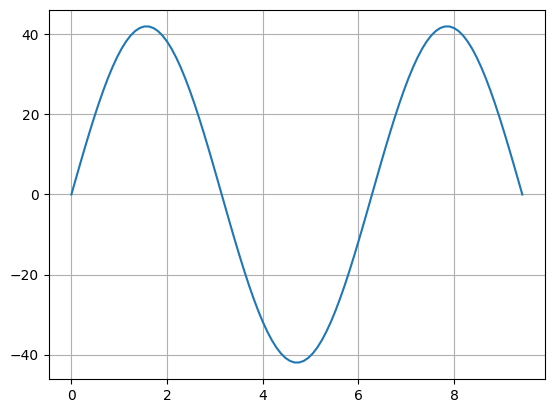

In [80]:
import matplotlib.pyplot as plt

x = np.linspace(0, 3*np.pi, 100)
y = 42 * np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)
ax.grid()
plt.show()